Initializing 2008 Global Financial Topology...
Network seeded. Entire system near critical boundary (η > 0.90)
Injecting subprime shock into top 5 hubs...
Cascade terminated after 4 topological steps.
Total Bank Failures: 500 out of 500


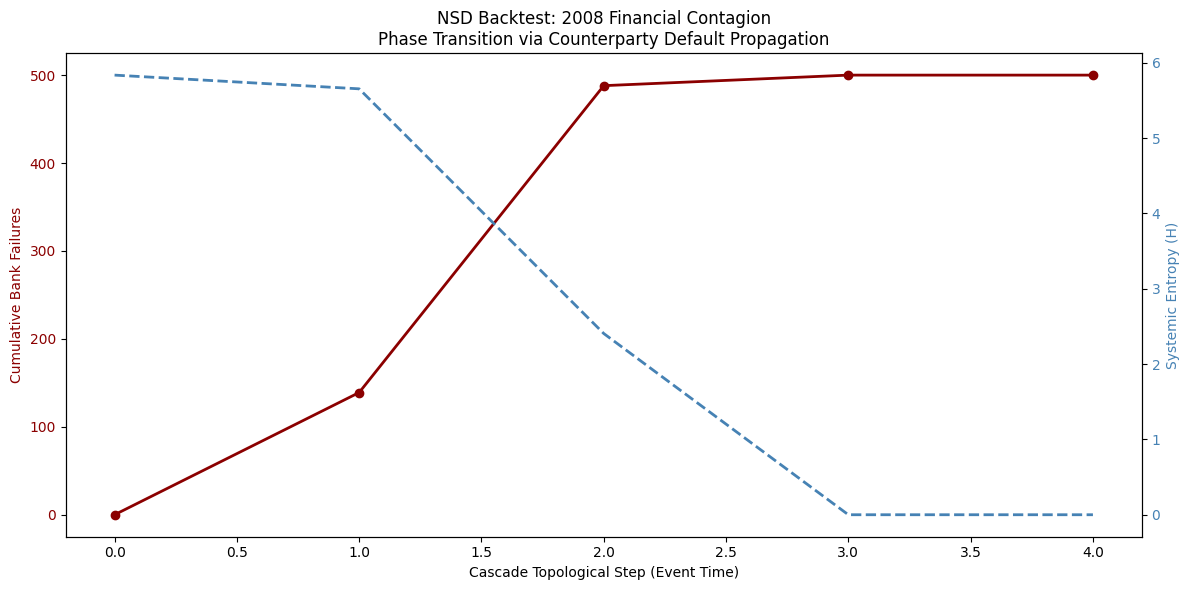

In [3]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

def simulate_2008_nsd_contagion(num_banks=500, m_edges=3):
    print("Initializing 2008 Global Financial Topology...")
    G = nx.barabasi_albert_graph(num_banks, m_edges)
    degrees = dict(G.degree())
    
    capacity = np.zeros(num_banks)
    stress = np.zeros(num_banks)
    
    # 1. Universal Hyper-Efficiency (The 2007 Environment)
    for i in range(num_banks):
        capacity[i] = max(10, degrees[i] * 50)
        
        # Hubs are at the absolute brink (η ≈ 0.98)
        if degrees[i] > 15:
            efficiency = np.random.uniform(0.97, 0.99) 
        # Peripherals are also highly leveraged (η ≈ 0.90 to 0.95)
        else:
            efficiency = np.random.uniform(0.90, 0.95)
            
        stress[i] = capacity[i] * efficiency

    print("Network seeded. Entire system near critical boundary (η > 0.90)")

    # 2. The Subprime Shock
    hubs = sorted(degrees, key=degrees.get, reverse=True)[:5]
    print(f"Injecting subprime shock into top 5 hubs...")
    for hub in hubs:
        # 5% shock instantly breaches the ~2% buffer of the hubs
        stress[hub] += capacity[hub] * 0.05 
        
    # 3. NSD Thermodynamic Cascade Loop
    active_cascade = True
    step = 0
    failed_banks = np.zeros(num_banks, dtype=bool)
    
    history_failed = [0]
    
    # Initial Entropy
    total_stress = np.sum(stress)
    p_stress = stress / total_stress
    p_stress = p_stress[p_stress > 0]
    history_entropy = [-np.sum(p_stress * np.log(p_stress))]
    
    while active_cascade and step < 50:
        step += 1
        new_failures = 0
        
        for i in range(num_banks):
            if not failed_banks[i] and stress[i] > capacity[i]:
                failed_banks[i] = True
                new_failures += 1
                
                # AXIOM 3: Counterparty Default Propagation
                # Instead of just the deficit, the bankruptcy inflicts a massive 
                # counterparty loss (e.g., 20% of the failed bank's total capacity)
                loss_given_default = capacity[i] * 0.20 
                
                neighbors = list(G.neighbors(i))
                surviving_neighbors = [n for n in neighbors if not failed_banks[n]]
                
                if surviving_neighbors:
                    overflow_per_neighbor = loss_given_default / len(surviving_neighbors)
                    for n in surviving_neighbors:
                        stress[n] += overflow_per_neighbor
                        
                capacity[i] = 0
                stress[i] = 0 
                
        history_failed.append(np.sum(failed_banks))
        
        # Systemic Entropy Calculation
        if np.sum(~failed_banks) > 0 and np.sum(stress) > 0:
            total_stress = np.sum(stress[~failed_banks])
            p_stress = stress[~failed_banks] / total_stress
            p_stress = p_stress[p_stress > 0]
            entropy = -np.sum(p_stress * np.log(p_stress))
        else:
            entropy = 0
        history_entropy.append(entropy)
        
        if new_failures == 0:
            active_cascade = False

    print(f"Cascade terminated after {step} topological steps.")
    print(f"Total Bank Failures: {history_failed[-1]} out of {num_banks}")

    # 4. Visualization
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    color1 = 'darkred'
    ax1.set_xlabel('Cascade Topological Step (Event Time)')
    ax1.set_ylabel('Cumulative Bank Failures', color=color1)
    ax1.plot(range(len(history_failed)), history_failed, color=color1, marker='o', linewidth=2, label='Failed Nodes')
    ax1.tick_params(axis='y', labelcolor=color1)
    
    ax2 = ax1.twinx()  
    color2 = 'steelblue'
    ax2.set_ylabel('Systemic Entropy (H)', color=color2)  
    ax2.plot(range(len(history_entropy)), history_entropy, color=color2, linestyle='--', linewidth=2, label='Systemic Entropy')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title('NSD Backtest: 2008 Financial Contagion\nPhase Transition via Counterparty Default Propagation')
    fig.tight_layout()  
    plt.show()

simulate_2008_nsd_contagion()